<a href="https://colab.research.google.com/github/anaghasurendran145-maker/mmmm/blob/main/Retail_Sales_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*RETAIL SALES FORECASTING*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv("/content/Features data set.csv",encoding='latin1')

In [5]:
df.head()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
Date,,,,,,,,,,,
2010-02-05,1,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
2010-02-12,1,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2010-02-19,1,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
2010-02-26,1,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
2010-03-05,1,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [3]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

In [4]:
monthly = df['CPI'].resample('M').mean()

/tmp/ipykernel_319/1562876008.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['CPI'].resample('M').mean()


**TREND ANALYSING**

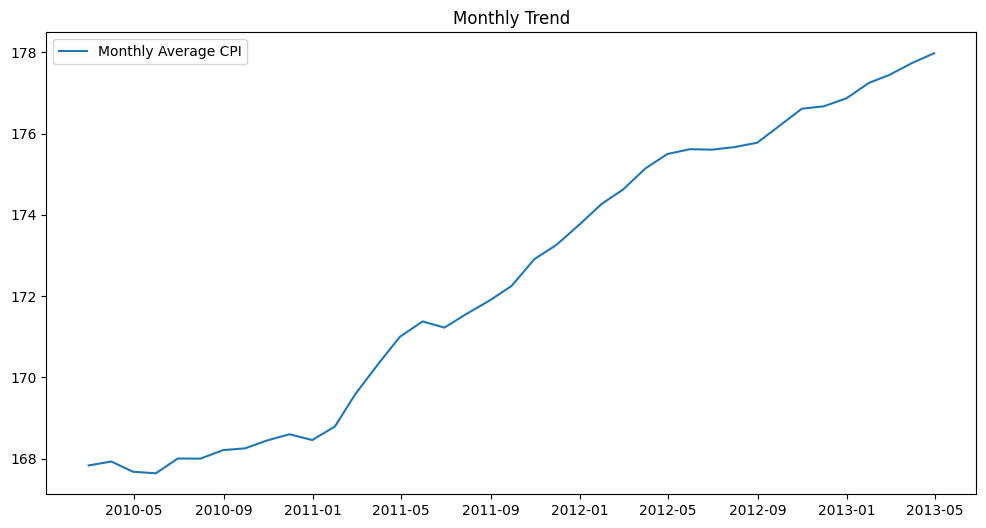

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(monthly, label='Monthly Average CPI')
plt.title('Monthly Trend')
plt.legend()
plt.show()

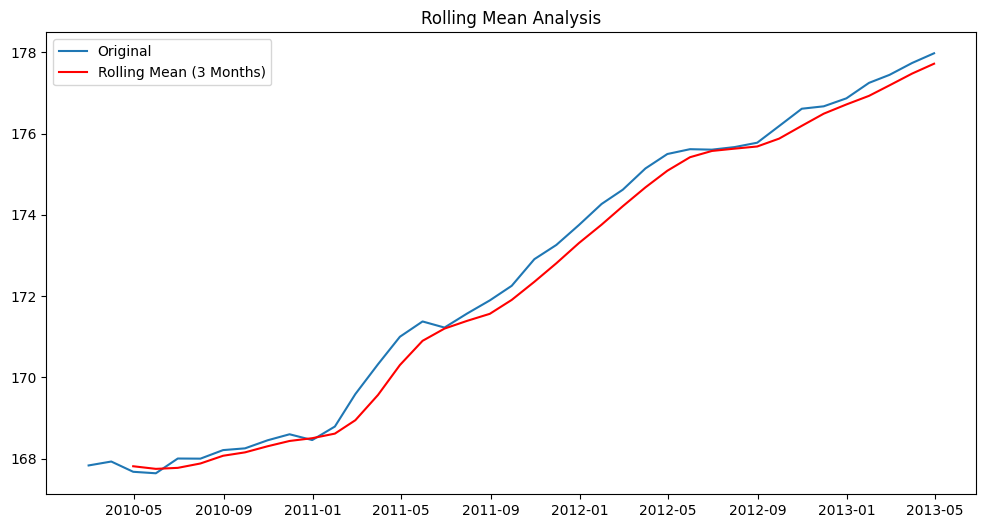

In [7]:
rolling_mean = monthly.rolling(window=3).mean()
plt.figure(figsize=(12, 6))
plt.plot(monthly, label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean (3 Months)')
plt.title('Rolling Mean Analysis')
plt.legend()
plt.show()

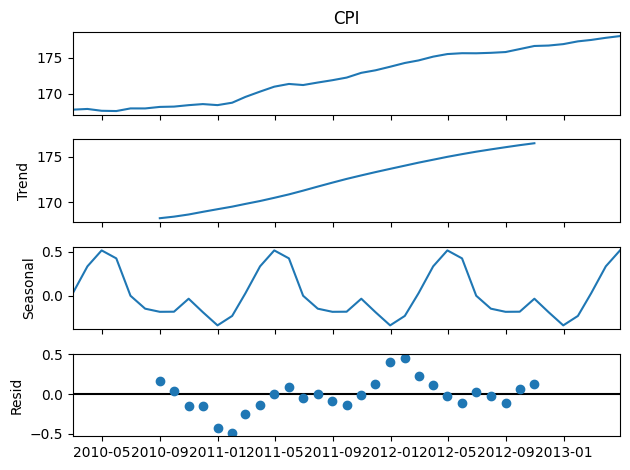

In [8]:
decomposition = seasonal_decompose(monthly.dropna(), model='additive')
decomposition.plot()
plt.show()

**TRAIN MODEL(ARIMA)**

In [9]:
model = ARIMA(monthly, order=(2, 1, 2))
result = model.fit()
print(result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                    CPI   No. Observations:                   42
Model:                 ARIMA(2, 1, 2)   Log Likelihood                   4.578
Date:                Tue, 24 Mar 2026   AIC                              0.843
Time:                        12:14:56   BIC                              9.411
Sample:                    02-28-2010   HQIC                             3.963
                         - 07-31-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5030      0.274      1.833      0.067      -0.035       1.041
ar.L2          0.4468      0.238      1.876      0.061      -0.020       0.914
ma.L1          0.1977      0.345      0.573      0.5

**FORECAST SALES**

In [10]:
forecast_steps = 12
forecast = result.get_forecast(steps=forecast_steps)
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

**PLOTTING FORECAST**

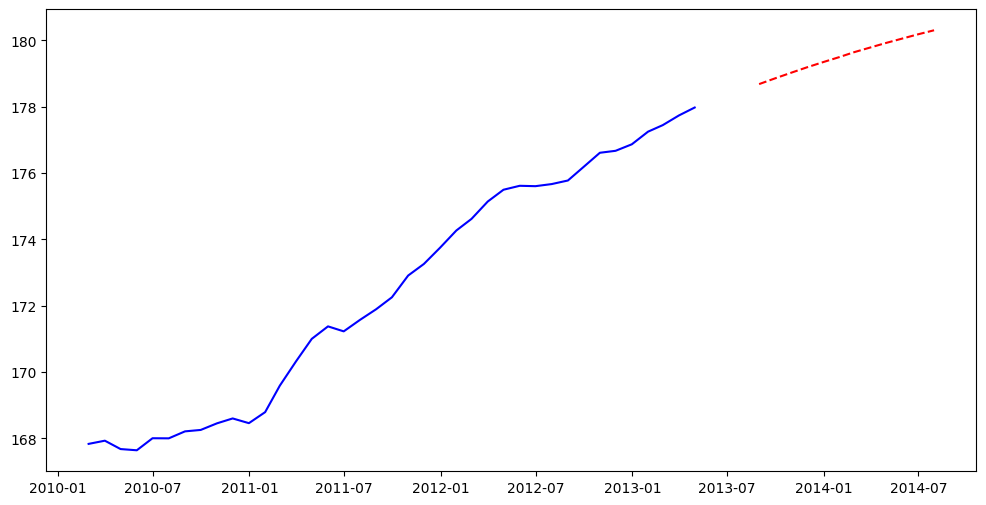

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(monthly, label='Historical Data', color='blue')
plt.plot(forecast_values, label='Forecasted Data', color='red', linestyle='--')

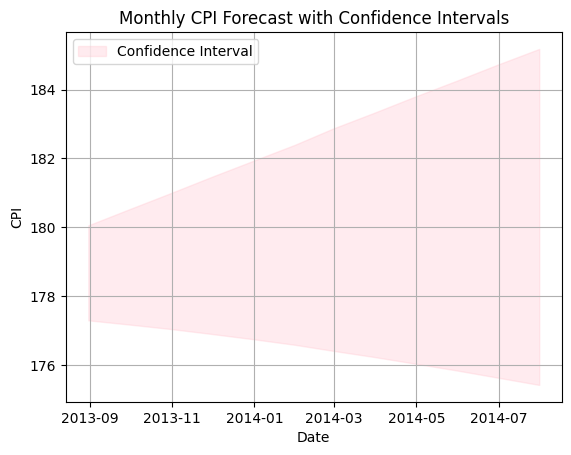

In [ ]:
plt.fill_between(confidence_intervals.index, confidence_intervals['lower CPI'], confidence_intervals['upper CPI'], color='pink', alpha=0.3, label='Confidence Interval')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.title('Monthly CPI Forecast with Confidence Intervals')
plt.legend()
plt.grid(True)
plt.show()

**INSIGHTS**

1.**MONTHLY TREND**

Retail business is growing year-over-year. While there are short-term dips, the "baseline" of sales is steadily climbing.

2.**SEASONALITY**

There is a heavy, repeating seasonal swing. In the retail context, this usually aligns with Q4 holiday shopping (November/December peaks) followed by Q1 slumps (January/February).

3.**FORECAST EVALUATION**

The forecast correctly anticipates the next seasonal dip before the next growth cycle begins.

**SUMMARY**

The retail environment is characterized by a strong growth trend and high seasonality.ARIMA model suggests that while values will continue to rise year-over-year, we should prepare for a significant seasonal cooling in the immediate coming months before the next peak.


Because of the heavy seasonality shown in the decomposition plot, the procurement team must stockpile inventory 2-3 months prior to the historical peak. Relying on a flat monthly average will cause massive stockouts during peak seasons.

